In [2]:
import cme.simulators.diffusion_random_walk as drw
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy.linalg as ln
import numpy as np
import matplotlib.animation as animation
from IPython.display import HTML

In [3]:
theta, alpha, tau, I, J = 3, 1.5, 0.01, 2,4

mu, sigma = np.asarray([1.2]), np.asarray([1])

n_states = drw.get_n_states(alpha, theta, tau, sigma)
dis_tran = drw.get_transition_matrix(alpha, tau, sigma[0], mu, process="Wiener", n_states=n_states)
n = int(np.ceil(4/tau))
likl = drw.disc_likl(n, n_states, dis_tran, stats.uniform().rvs((1,n_states-2)))
n_states, likl

(39, array([[0.00011195, 0.00087543]]))

mu1, sigma1 = np.tile(1.2,(I,1)), np.asarray([1])

n_states = drw._get_n_states(alpha, theta, tau, sigma1)
dis_tran = drw.get_transition_matrix(alpha, tau, sigma[0], mu1, process="Wiener", n_states=n_states)
n = int(np.ceil(4/tau))
likl = drw.disc_likl(n, n_states, dis_tran, stats.uniform().rvs((1,n_states-2)))
likl.shape

In [4]:
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma[0], mu,samples = 1, process="Wiener",
                                        njobs=1, scale_steps_to_boundary=True)
RT_arr

[1.43]

sns.kdeplot(RT_arr)

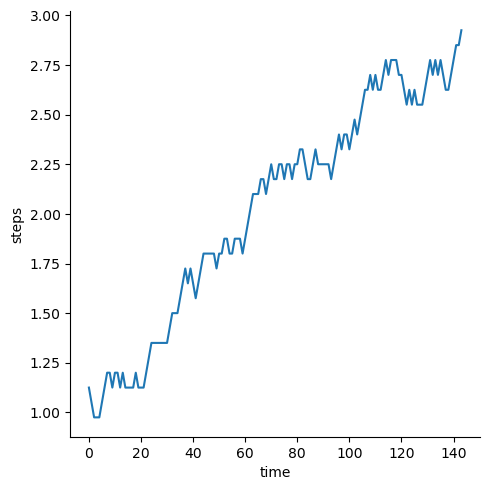

In [5]:
sns.relplot(pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time"),
x="time",
y="steps", kind="line")

import plotly.express as px
df = pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time")
px.scatter(df, x="time", y="steps", animation_frame="time", 
            range_x=[0,200], range_y=[0,50])
           
           #animation_group="country",
#)#log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

In [6]:
len(steps_arr[0])

144

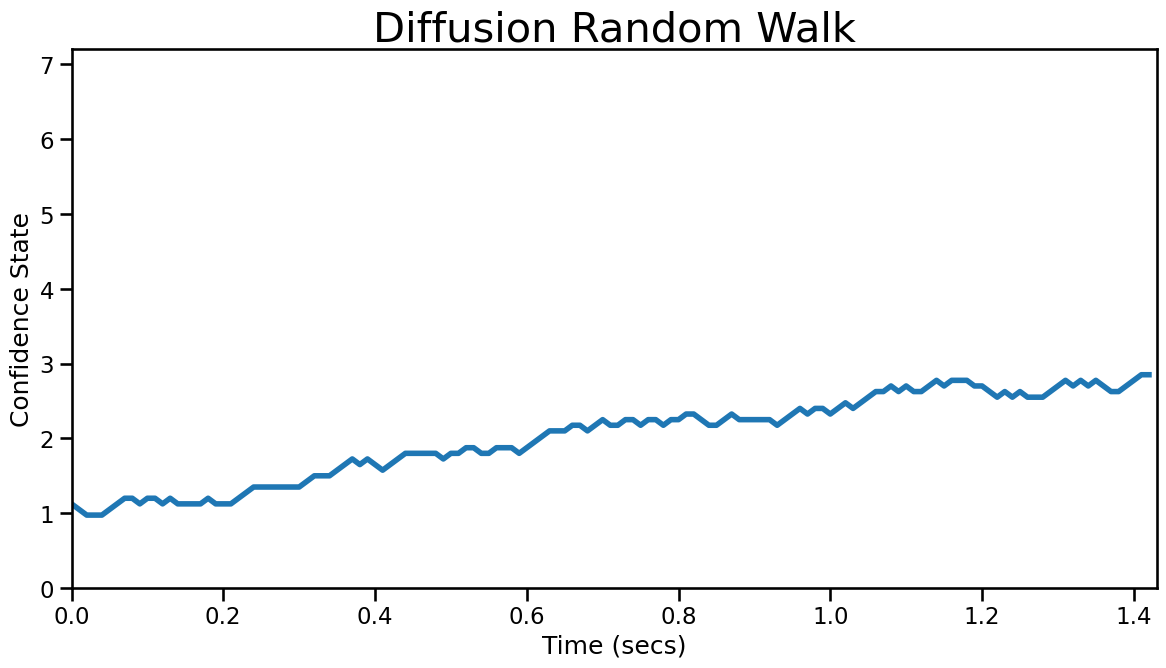

In [7]:

# Example Data
time = np.arange(len(steps_arr[0])) * 0.01

with sns.plotting_context("talk"):
    fig, ax = plt.subplots(figsize=(14,7))
ax.set_xlim(0, time.max())
ax.set_ylim(0, 7.2)
ax.set_xlabel("Time (secs)")
ax.set_ylabel("Confidence State")
ax.set_title("Diffusion Random Walk", fontsize=30)
line, = ax.plot([], [], lw=4)

def update(frame):
    line.set_data(time[:frame], steps_arr[0][:frame])
    return line,

ani = animation.FuncAnimation(fig, update, frames=len(time), interval=1, blit=True)

ani.save("export/diffusion_walk_discrete_time.gif", writer="pillow", fps=30)

# Save as MP4
#plt.rcParams['animation.ffmpeg_path'] = '/usr/bin/ffmpeg'
#ani.save("export/diffusion_walk_discrete_time.mp4", writer="ffmpeg", fps=30)

#WriterClass = animation.writers['ffmpeg']
#writer = WriterClass(fps=10, metadata=dict(artist='bww'), bitrate=1800)
#writer = animation.FFMpegFileWriter(fps=30)
#ani.save('export/diffusion_walk_discrete_time.mp4', writer=writer)

#print("Video saved as animation.mp4")
# from IPython.display import HTML
# HTML(ani.to_jshtml())

In [ ]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

n_states_q, start_width, response_width = 3, None, 1
start_width = (n_states_q-2*response_width) 
mv = np.arange(-(n_states_q//2), (n_states_q//2)+1)

m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states_q, 1, prob=0.5, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states_q, 1, prob=0.5, model_type = "Quantum")

df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()
df_quantum_internal_1 = pd.DataFrame()

intensity_matrix_markov = dd._buildK(n_states_q, np.asarray([[1]]), np.asarray([[2]]), boundary_type = "Internal")
intensity_matrix_quantum = qd._buildH(n_states_q, np.asarray([[2]]), np.asarray([[1]]))

prior_type  = ["Centered", "Lower"]

phi_0_markov = ca._get_initial_state(n_states_q, start_width, response_width, model_type="Markov" , prior_type=prior_type[0])
phi_0_quantum = ca._get_initial_state(n_states_q, start_width, response_width, model_type="Quantum" , prior_type=prior_type[1])

phi_quantum_amplitude_arr = []
phi_quantum_alldist_arr = []
phi_quantum_arr = []
phi_markov_arr = []

phi_markov_internal_arr = []
phi_quantum_internal_arr = [] 
phi_quantum_internal_mv_arr = []

phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
phi_markov_internal_arr.append(np.asarray(phi_0_markov.squeeze()))

phi_quantum_internal_arr.append(np.abs(phi_0_quantum.squeeze())**2)
phi_quantum_alldist_arr.append(np.abs(phi_0_quantum.squeeze())**2)
phi_quantum_amplitude_arr.append(phi_0_quantum.squeeze())

delta=0.01
for t in np.arange(delta,10,delta):
    phi_markov = ca.perform_state_transition(intensity_matrix_markov, np.asarray([[t]]), np.asarray([[1]]), 
                                            m_Mc, m_Mw, m_Mn, phi_0_markov, 0.1, 
                                            transition_type="RT", likelihood_type="SINGLE")
    phi_internal_markov = ca.perform_state_transition(intensity_matrix_markov, np.asarray([[t]]), np.asarray([[1]]), 
                                            m_Mc, m_Mw, m_Mn, phi_0_markov, 0.1, 
                                            transition_type="TIMESTEP", likelihood_type="SINGLE")

    phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, np.asarray([[t]]), np.asarray([[1]]), 
                                            q_Mc, q_Mw, q_Mn, phi_0_quantum, 0.1, 
                                            transition_type="RT", likelihood_type="SINGLE")
    phi_quantum_internal = ca.perform_state_transition(intensity_matrix_quantum, np.asarray([[t]]), np.asarray([[1]]), 
                                            q_Mc, q_Mw, q_Mn, phi_0_quantum, 0.1, 
                                            transition_type="TIMESTEP", likelihood_type="SINGLE")
    
    phi_markov_arr.append(phi_markov.squeeze())
    phi_markov_internal_arr.append(phi_internal_markov.squeeze())

    phi_quantum_amplitude_arr.append(phi_quantum.squeeze())
    phi_quantum_internal_arr.append(np.abs(phi_quantum_internal.squeeze())**2)
    phi_quantum_alldist_arr.append(np.abs(phi_quantum.squeeze())**2)
    phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
    phi_quantum_internal_mv_arr.append((np.abs(phi_quantum_internal.squeeze())**2) @ mv)


df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type[0], mu="2,1")])
df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type[1], mu="2,1")])
df_quantum_internal_1 = pd.concat([df_quantum_internal_1, pd.DataFrame(phi_quantum_internal_mv_arr).T.assign(prior=prior_type[1], mu="1,1")])
        

In [9]:
mv_n = ["High Conf (Incorrect)", "No Response", "High Conf (Correct)"]
custom_color = {mv_n[0]:"Red", mv_n[1]:"Orange", mv_n[2]:"Green"}

In [20]:
df_d = (pd.DataFrame(np.asarray(phi_markov_arr))
        .rename(columns=dict(zip(np.arange(n_states_q), mv_n)))
        .reset_index(names="time")
        .melt(id_vars="time", var_name="state", value_name="prob").astype({"state":"category"})
        .assign(time=lambda df:df.time*delta)
        .assign(state = lambda df:pd.Categorical(df.state, categories = mv_n[::-1]))
        .query("time <= 6")
 )
df_d

,time,state,prob
0,0.00,High Conf (Incorrect),0.333333
1,0.01,High Conf (Incorrect),0.334983
2,0.02,High Conf (Incorrect),0.336601
3,0.03,High Conf (Incorrect),0.338186
4,0.04,High Conf (Incorrect),0.339740
...,...,...,...
2596,5.96,High Conf (Correct),0.583332
2597,5.97,High Conf (Correct),0.583332
2598,5.98,High Conf (Correct),0.583332
2599,5.99,High Conf (Correct),0.583332


In [17]:
df_d_i = (pd.DataFrame(np.asarray(phi_markov_internal_arr))
        .rename(columns=dict(zip(np.arange(n_states_q), mv_n)))
        .reset_index(names="time")
        .melt(id_vars="time", var_name="state", value_name="prob").astype({"state":"category"})
        .assign(time=lambda df:df.time*delta)
        .assign(state = lambda df:pd.Categorical(df.state, categories = mv_n[::-1]))
        .query("time <= 6")
 )
df_d_i

,time,state,prob
0,0.00,High Conf (Incorrect),3.333333e-01
1,0.01,High Conf (Incorrect),6.683168e-01
2,0.02,High Conf (Incorrect),6.699342e-01
3,0.03,High Conf (Incorrect),6.715196e-01
4,0.04,High Conf (Incorrect),6.730736e-01
...,...,...,...
2596,5.96,High Conf (Correct),1.279155e-06
2597,5.97,High Conf (Correct),1.312104e-06
2598,5.98,High Conf (Correct),1.344401e-06
2599,5.99,High Conf (Correct),1.376058e-06


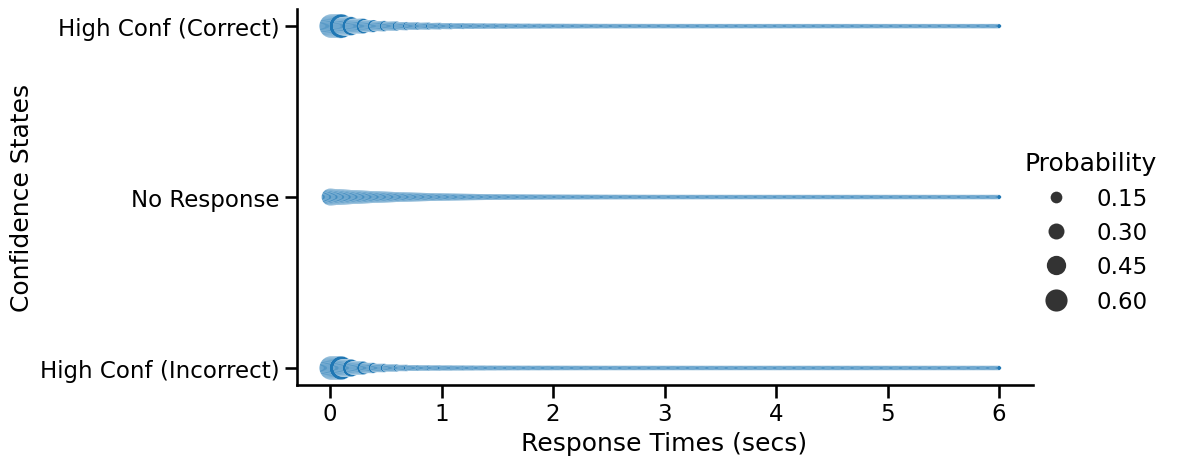

In [18]:
with sns.plotting_context("talk"):
    g = sns.relplot(df_d_i,
x="time", #order = mv_n,
y="state",
size="prob", sizes=(10,300), aspect=2.2)
#g.figure.set_size_inches(28,5)
g.legend.set_title("Probability")
g.set_ylabels("Confidence States")
g.set_xlabels("Response Times (secs)")

import matplotlib.animation as animation

# Prepare the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(df_d["time"].min(), df_d["time"].max())
ax.set_ylim(df_d["prob"].min(), df_d["prob"].max())
ax.set_xlabel("Time")
ax.set_ylabel("Probability")
ax.set_title("State Probability Over Time")

# Initialize scatter plot
scatter = ax.scatter([], [], s=[], alpha=0.6)

# Update function for animation
def update(frame):
    current_time = frame * delta
    df_frame = df_d[df_d["time"] <= current_time]
    scatter.set_offsets(df_frame[["time", "state"]])
    scatter.set_sizes(df_frame["prob"] * 500)
    return scatter,

# Create animation
framesno = int(df_d["time"].max() / delta) + 1
ani = animation.FuncAnimation(fig, update, frames=framesno, interval=200, blit=True)

# Save the animation as a GIF
ani.save("state_probability_animation.gif", writer="pillow", fps=10)

# Display animation in Jupyter Notebook
plt.show()

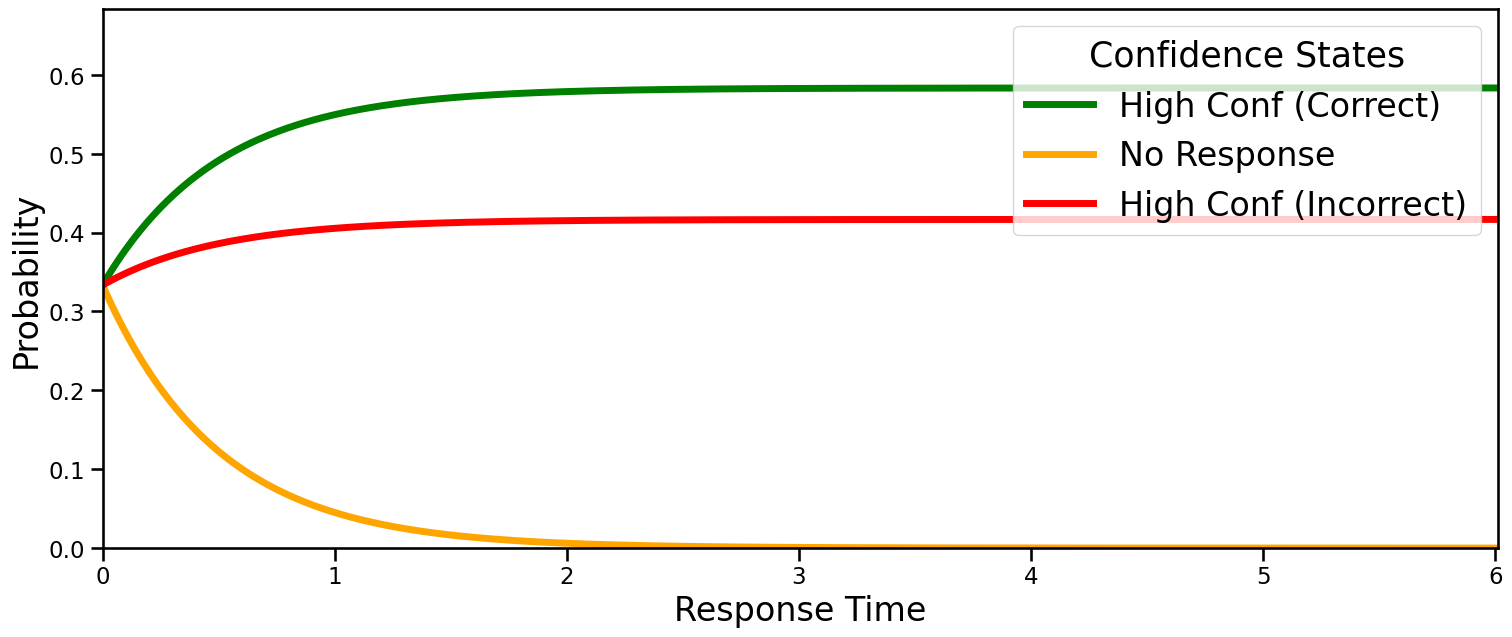

In [21]:
import matplotlib.animation as animation

# Prepare the plot
with sns.plotting_context("talk"):
    fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(df_d["time"].min(), df_d["time"].max()+delta)
ax.set_ylim(0, df_d["prob"].max() + 0.1)
ax.set_xlabel("Response Time", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
#ax.set_title('Diffision "Probability" Walk', fontsize=30)

lines = {}
states = df_d["state"].unique()[::-1]

# Create line objects for each state
for state in states:
    ms, ls, lw = (15, "-", 4) if "Correct" in state else (10, ":", 1) if "No" in state else (5, "--", 2)
    line, = ax.plot([], [], linestyle="-", lw=5,label=f"{state}", color=custom_color[state])#, lw=3.5) #marker="o", markersize=ms, l
    lines[state] = line

ax.legend(title='Confidence States', title_fontsize=25, fontsize=24, loc='upper right')

# Update function for animation
def update(frame):
    df_frame = df_d[df_d["time"] <= frame * delta]  # Include only data up to current time step
    for state in states:
        subset = df_frame[df_frame["state"] == state]
        lines[state].set_data(subset["time"], subset["prob"])
    return lines.values()

# Create animation
framesno = int(df_d["time"].max() / delta) + 1
ani = animation.FuncAnimation(fig, update, frames=framesno, interval=200, repeat=False, blit=False, cache_frame_data=False)

# Save the animation as a GIF
ani.save("export/diffusion_walk_continuous_time.gif", writer="pillow", fps=30)
#ani.save("export/diffusion_walk_continuous_time.mp4", writer="ffmpeg", fps=30)
#ani#.to_html5_video()
# Display animation in Jupyter Notebook
# HTML(ani.to_jshtml())
plt.show()

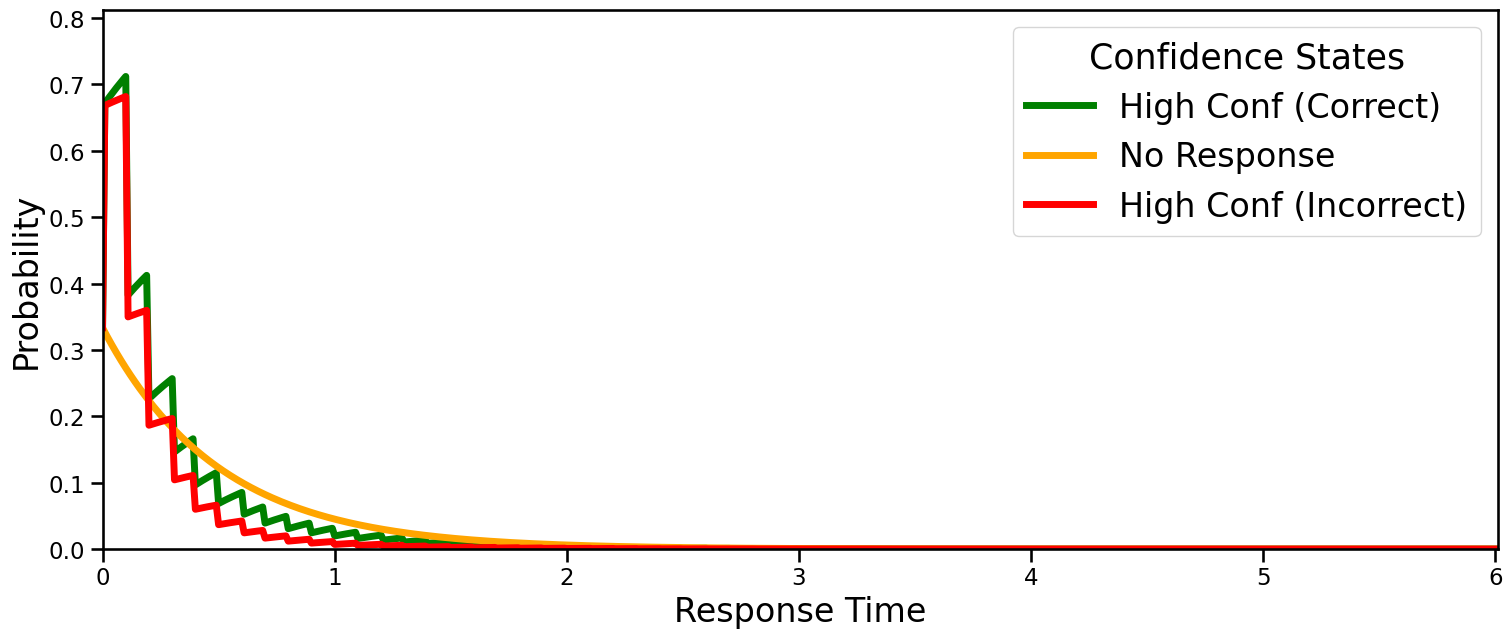

In [22]:
import matplotlib.animation as animation

# Prepare the plot
with sns.plotting_context("talk"):
    fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(df_d_i["time"].min(), df_d_i["time"].max()+delta)
ax.set_ylim(0, df_d_i["prob"].max() + 0.1)
ax.set_xlabel("Response Time", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
#ax.set_title('Diffision "Probability" Walk', fontsize=30)

lines = {}
states = df_d_i["state"].unique()[::-1]

# Create line objects for each state
for state in states:
    ms, ls, lw = (15, "-", 4) if "Correct" in state else (10, ":", 1) if "No" in state else (5, "--", 2)
    line, = ax.plot([], [], linestyle="-", lw=5,label=f"{state}", color=custom_color[state])#, lw=3.5) #marker="o", markersize=ms, l
    lines[state] = line

ax.legend(title='Confidence States', title_fontsize=25, fontsize=24, loc='upper right')

# Update function for animation
def update(frame):
    df_frame = df_d_i[df_d_i["time"] <= frame * delta]  # Include only data up to current time step
    for state in states:
        subset = df_frame[df_frame["state"] == state]
        lines[state].set_data(subset["time"], subset["prob"])
    return lines.values()

# Create animation
framesno = int(df_d_i["time"].max() / delta) + 1
ani = animation.FuncAnimation(fig, update, frames=framesno, interval=200, repeat=False, blit=False, cache_frame_data=False)

# Save the animation as a GIF
ani.save("export/diffusion_walk_internal_continuous_time.gif", writer="pillow", fps=30)
#ani#.to_html5_video()
# Display animation in Jupyter Notebook
# HTML(ani.to_jshtml())
plt.show()

In [ ]:
df_q_amp = (pd.DataFrame(np.asarray(phi_quantum_amplitude_arr))
            .rename(columns=dict(zip(np.arange(n_states_q), mv_n)))
            .reset_index(names="time")
            .melt(id_vars="time", var_name="state", value_name="prob")
            .assign(time=lambda df:df.time*0.01)#, state = lambda df:df.state+1).astype({"state":"category"})
)
df_q_amp.loc[:,"real"] = np.real(df_q_amp.prob)
df_q_amp.loc[:,"img"] = np.imag(df_q_amp.prob)
df_q_amp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

# Sample DataFrame
# df_q_amp = pd.DataFrame({
#     'time': np.linspace(0, 10, 100),
#     'state': np.random.randint(0, 4, 100),
#     'real': np.sin(np.linspace(0, 10, 100)),
#     'img': np.cos(np.linspace(0, 10, 100))
# })

# Create colormap for states
unique_states = df_q_amp['state'].unique()
colors = plt.cm.jet(np.linspace(0, 1, len(unique_states)))
state_color_map = {state: color for state, color in zip(unique_states, colors)}
with sns.plotting_context("talk"):
    fig = plt.figure(figsize=(13, 13))
    ax = fig.add_subplot(111, projection='3d')

# Plot each state as a separate line with its respective color
for state in unique_states:
    subset = df_q_amp[df_q_amp['state'] == state]
    ax.plot(subset['time'], subset['real'], subset['img'], color=state_color_map[state], label=f'State {state}')

ax.set_xlabel('Time')
ax.set_ylabel('Real')
ax.set_zlabel('Imaginary')
ax.set_title('Quantum State Evolution', fontsize=30)

# Add legend
ax.legend(title="Confidence State")
#ax.view_init(elev=10, azim=58, roll=0)

ax.legend(title="Confidence State", fontsize=18, title_fontsize=20, bbox_to_anchor=(1.3,0.8))
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors

# Sample DataFrame
# df_q_amp = pd.DataFrame({
#     'time': np.linspace(0, 10, 100),
#     'state': np.random.randint(0, 4, 100),
#     'real': np.sin(np.linspace(0, 10, 100)),
#     'img': np.cos(np.linspace(0, 10, 100))
# })

# Create colormap for states
unique_states = df_q_amp['state'].unique()
colors = plt.cm.jet(np.linspace(0, 1, len(unique_states)))
state_color_map = {state: color for state, color in zip(unique_states, colors)}
with sns.plotting_context("talk"):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

# Plot each state as a separate line with its respective color
for state in unique_states:
    subset = df_q_amp[df_q_amp['state'] == state]
    ax.plot(subset['time'], subset['real'], subset['img'], color=state_color_map[state], label=f'{state}', lw=2)

ax.set_xlabel('Time', labelpad=5, fontsize=25)
ax.set_ylabel('Real', labelpad=25, fontsize=25)
ax.set_zlabel('Imaginary', labelpad=20, fontsize=25)
ax.set_title('Quantum State Evolution', fontsize=30)

# Add legend
ax.legend(title="Confidence State")
#ax.view_init(elev=10, azim=58, roll=0)
#ax.view_init(elev=25, azim=-80, roll=-10)
ax.view_init(elev=110, azim=-90)
ax.legend(title="Confidence State", fontsize=18, title_fontsize=20, bbox_to_anchor=(1.3,0.8))
plt.show()


In [ ]:
len(df_q_amp), int(df_q_amp["time"].max()/0.01)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

# Sample DataFrame
# df_q_amp = pd.DataFrame({
#     'time': np.linspace(0, 10, 100),
#     'state': np.random.randint(0, 4, 100),
#     'real': np.sin(np.linspace(0, 10, 100)),
#     'img': np.cos(np.linspace(0, 10, 100))
# })

# Get unique states and assign colors
unique_states = df_q_amp['state'].unique()
#colors = plt.cm.jet(np.linspace(0, 1, len(unique_states)))
#state_color_map = {state: color for state, color in zip(unique_states, colors)}

with sns.plotting_context("talk"):
    fig = plt.figure(figsize=(11, 11))
    ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(df_q_amp['time'].min(), df_q_amp['time'].max())
ax.set_ylim(df_q_amp['real'].min(), df_q_amp['real'].max())
ax.set_zlim(df_q_amp['img'].min(), df_q_amp['img'].max())


# Set labels and title
ax.set_xlabel('Time', labelpad=5, fontsize=25)
ax.set_ylabel('Real', labelpad=20, fontsize=25)
ax.set_zlabel('Imaginary', labelpad=20, fontsize=25)
ax.set_title('Quantum "Amplitude" Walk', fontsize=30)

# Initialize empty line objects for each state
lines = {state: ax.plot([], [], [], label=f'{state}', lw=4, color=custom_color[state])[0] for state in unique_states}

# Animation function
def update(frame):
    for state in unique_states:
        subset = df_q_amp[df_q_amp['state'] == state]
        lines[state].set_data(subset['time'][:frame], subset['real'][:frame])  # Update X and Y
        lines[state].set_3d_properties(subset['img'][:frame])  # Update Z
    return lines.values()

#ax.view_init(elev=25, azim=-80, roll=-10)
ax.view_init(elev=110, azim=-90)
ax.legend(title="Confidence State", fontsize=12, title_fontsize=15, bbox_to_anchor=(1.1,1))
# Create animation
frameno = int(df_q_amp["time"].max()/0.01) + 1#1000 #len(df_q_amp) #50
ani = animation.FuncAnimation(fig, update, frames=frameno, interval=100, blit=True) #len(df_q_amp)
ani.save("export/quantum_amplitude_walk_discrete_time.gif", writer="pillow", fps=30)
# Show animation


#plt.show()
#HTML(ani.to_jshtml())

In [ ]:
df_q = (pd.DataFrame(np.asarray(phi_quantum_alldist_arr))
        .rename(columns=dict(zip(np.arange(n_states_q), mv_n)))
        .reset_index(names="time")
        .melt(id_vars="time", var_name="state", value_name="prob").astype({"state":"category"})
        .assign(time=lambda df:df.time*delta)
        .query("time < 6")
        .assign(state = lambda df:pd.Categorical(df.state, categories = mv_n[::-1]))
 )
df_q


sns.relplot(
    df_q, x="time", y="prob", hue="state", kind="line", aspect=2
)

In [ ]:
with sns.plotting_context("talk"):
    g = sns.relplot(df_q,
x="time", #order = mv_n,
y="state",
size="prob", sizes=(10,400), aspect=2.2)
#g.figure.set_size_inches(28,5)
g.legend.set_title("Probability")
g.set_ylabels("Confidence States")
g.set_xlabels("Response Times (secs)")

In [ ]:
df_all = df_d.query("time == 2").rename(columns={"prob":"Diffusion"}).merge(
df_q.query("time == 2").rename(columns={"prob":"Quantum"}), on=["time", "state"] ).melt(id_vars=["time", "state"])
df_all

In [ ]:
with sns.plotting_context("talk", font_scale=1.4):
    g = sns.pointplot(df_all, 
hue="variable", #order = mv_n,
x="state", lw=6,
y="value", )#sizes=(10,400))#, aspect=1.5)
#g.figure.set_size_inches(28,5)
#g.legend.set_title("Probability")
#g.legend.set_bbox_to_anchor((0.9,0.5))
g.set_ylabel("Probability")
g.set_title("Probability Distribution at Response Time = 2", fontsize=25, y=1.05)
g.set_xlabel("")
g.get_legend().set_title("")
g.figure.set_size_inches(15,5)
plt.xticks(rotation=20, ha='right') 
#sns.move_legend(loc="upper right", obj = g)

In [ ]:
# Prepare the plot
with sns.plotting_context("talk"):
    fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(df_q["time"].min(), df_q["time"].max()+delta)
ax.set_ylim(0, df_q["prob"].max() + 0.1)
ax.set_xlabel("Time (secs)", fontsize=24)
ax.set_ylabel("Probability", fontsize=24)
#ax.set_title('Quantum Probability "Walk"', fontsize=30)

lines = {}
states = df_q["state"].unique()[::-1]

# Create line objects for each state

for state in states:
    #ms, ls, lw = (15, "-", 5) if "Correct" in state else (10, ":", 3) if "No" in state else (5, "--", 1)
    line, = ax.plot([], [], linestyle= "-", lw=5, label=f"{state}", color=custom_color[state]) # marker = 'o', markersize=ms, lw = lw,  
    lines[state] = line

ax.legend(title="Confidence State", title_fontsize=25, fontsize=24, loc='upper right')

# Update function for animation
def update(frame):
    
    df_frame = df_q[df_q["time"] <= frame*delta]  # Include only data up to current time step
    #print(frame, df_frame.shape)
    for state in states:
        subset = df_frame[df_frame["state"] == state]
        lines[state].set_data(subset["time"], subset["prob"])
    return lines.values()

# Create animation
framesno = int(df_q["time"].max()/delta) + 1
ani = animation.FuncAnimation(fig, update, frames=framesno, repeat=False, interval=200, blit=False)
ani.save("export/quantum_walk_continuous_time.gif", writer="pillow", fps=30)
# Display animation in Jupyter Notebook
#HTML(ani.to_jshtml())
plt.show()

In [ ]:
theta, alpha, tau, sigma = 2.219, 1.5, 0.01, np.asarray([1])
steps = drw.get_n_states(alpha, theta, tau, sigma)
drw._scale_steps_by_boundary(steps, alpha, tau, sigma)

In [ ]:
np.asarray(steps_arr[0])

In [ ]:
drw._scale_steps_by_boundary(66, alpha, tau, sigma)

In [ ]:
# plot for NDAR_INV01AJ15N9
# alpha: 2.2198321041134936	beta:0.6202451435615302	delta:1.964868726067117	nondecision:0.3208593807756497	rt_mean: 0.7831230833333334

theta, alpha, tau = 2.2198321041134936, 1.5, 0.01

mu, sigma = np.asarray([1.964868726067117]), np.asarray([1])
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma, mu,samples = 1, process="Wiener",njobs=1, scale_steps=True)
ax = sns.lineplot(pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time"),
x="time",
y="steps")
ax.axhline(y=theta)


In [ ]:
np.asarray(steps_arr[0])

In [ ]:
drw._scale_steps_by_boundary(29, alpha, tau, sigma)

In [ ]:
steps_arr[0].shape